In [18]:
library(dplyr)
simulate_data <- function(n, beta_true, sigma = 1) {
# Generate 10 independent covariates from N(0, 1)
X <- matrix(rnorm(n * 10), nrow = n, ncol = 10)
design <- cbind(Intercept = 1, X)
# Calculate Y based on the first four covariates and intercept
Y <- (design %*% beta_true) + rnorm(n, mean = 0, sd = sigma)
return(data.frame(Y = Y, X))
}
set.seed(123) # For reproducibility
sample_sizes <- c(50, 100, 150, 200, 500, 1000, 5000)
beta_true <- c(10, 0.25, 0.25, 0.1, 0.1, 0, 0, 0, 0, 0, 0)
names(beta_true) <- c(
"(Intercept)", paste0("X", 1:10)
)
data_list <- lapply(sample_sizes, function(n) {
replicate(100, simulate_data(n, beta_true), simplify = FALSE)
})


Attache Paket: 'dplyr'


Die folgenden Objekte sind maskiert von 'package:stats':

    filter, lag


Die folgenden Objekte sind maskiert von 'package:base':

    intersect, setdiff, setequal, union




In [19]:
library(MASS)
eval_simulation <- function(sim_dta, beta_true) {
lm_full <- lm(Y ~
., data = sim_dta)
stepAIC_run <- stepAIC(lm_full, trace = FALSE)

# Extract coefficients and confidence intervals
coef_run <- coef(stepAIC_run)
conf_int <- confint(stepAIC_run)
# Bind true beta to coefficients
conf_df <- as.data.frame(conf_int) |>
mutate(beta_true = beta_true[names(coef_run)],
coefficient = row.names(conf_int))
conf_df |>
mutate(in_confint = between(beta_true, `2.5 %`, `97.5 %`)) |>
dplyr::select(coefficient, in_confint) |>
mutate(estimate = coef_run)
}


Attache Paket: 'MASS'


Das folgende Objekt ist maskiert 'package:dplyr':

    select




In [20]:
# Evaluate for all data sets
start = Sys.time()
# Run evaluation for all data sets
results <- lapply(data_list, function(data) {
lapply(data, FUN = function(dataset) {
eval_simulation(dataset, beta_true = beta_true)
})
})
# Convert to tibble for summary
coverage <- bind_rows(
lapply(
results, function(df) bind_rows(df, .id = "replication")
),
.id = "sample_size"
) |>
mutate(
sample_size = as.integer(sample_size),
# switch sample size with the elements of sample_sizes
sample_size = sample_sizes[sample_size]
)
Sys.time() - start
## Time difference of 14.62565 secs

Time difference of 9.190073 secs

`summarise()` has grouped output by 'coefficient'. You can override using the
`.groups` argument.


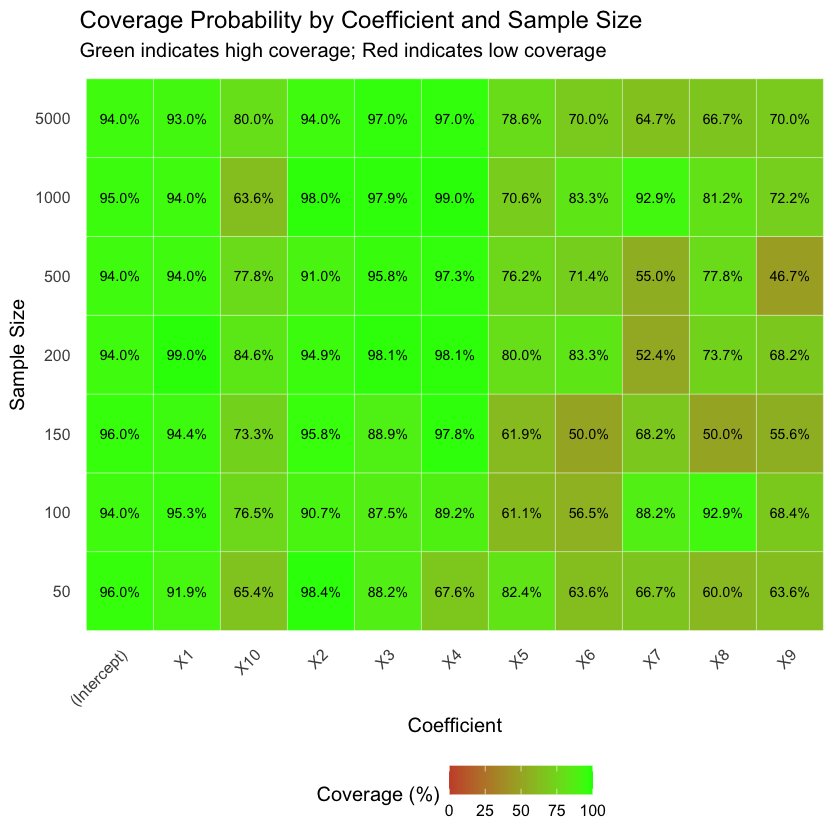

In [21]:
# Check confidence intervals and calculate coverage probabilities per var
library(ggplot2)
coverage |>
group_by(coefficient, sample_size) |>
summarize(inconf_perc = 100 * mean(in_confint)) |>
ggplot(aes(x = coefficient, y = factor(sample_size), fill = inconf_perc)) +
geom_tile(color = "white") +
geom_text(aes(label = sprintf("%.1f%%", inconf_perc)), color = "black", size = 3) +
scale_fill_gradient(low = "#c95136", high = "green",
limits = c(0, 100), name = "Coverage (%)") +
labs(
x = "Coefficient",
y = "Sample Size",
title = "Coverage Probability by Coefficient and Sample Size",
subtitle = "Green indicates high coverage; Red indicates low coverage"
) +
theme_minimal(base_size = 12) +
theme(
axis.text.x = element_text(angle = 45, hjust = 1),
panel.grid = element_blank(),
legend.position = "bottom"
)

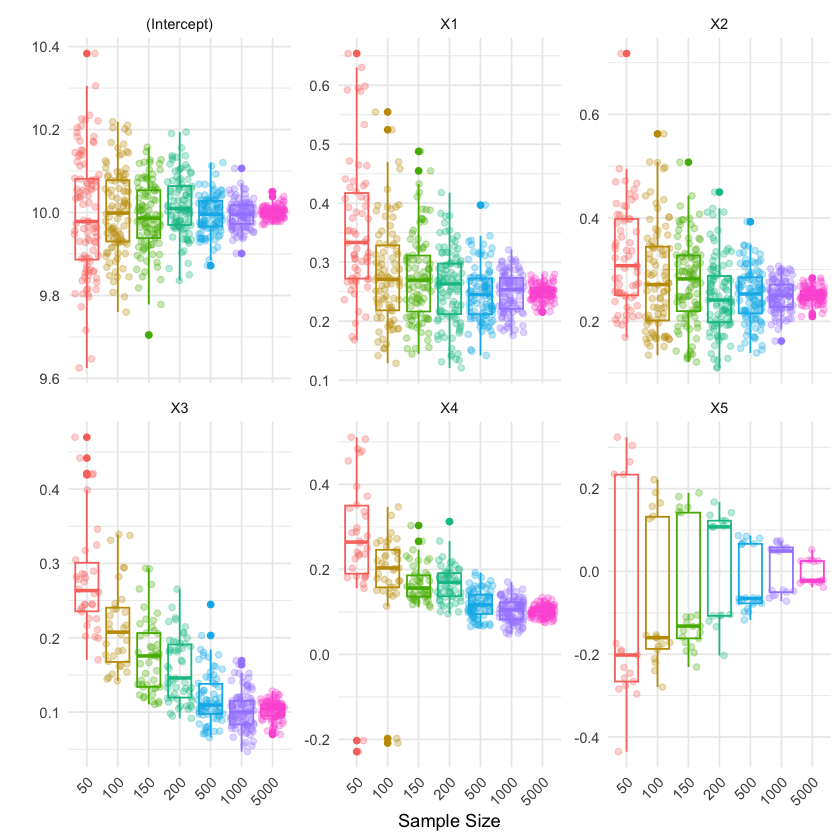

In [23]:
ggplot(
coverage |>
filter(coefficient %in% names(beta_true)[1:6]),
aes(x = factor(sample_size), y = estimate, colour = factor(sample_size))
) +
geom_boxplot(fill = NA) +
geom_jitter(alpha = 0.3) +
facet_wrap(~coefficient, scales = "free_y", ncol = 3) +
labs(x = "Sample Size", y = "") +
theme_minimal() +
theme(
legend.position = "none",
axis.text.x = element_text(angle = 45, hjust = 1)
) 